# Stronger weight decay with 25 labelled images

**Stage 4 targeted experiment.** Notebook 04 showed large train–validation differences and rising late validation loss for both saved n=25 training-image selections. This report tests one predeclared intervention: increasing AdamW weight decay from `1e-4` to `1e-2`, with every other training condition held fixed. Four new runs are compared with four existing references; the locked geographic test region remains unused.

## 1. Hypothesis and paired design

The hypothesis is that stronger parameter shrinkage may reduce overfitting and improve validation performance when only 25 labelled images are available. Each subset seed (17 and 29) and initialization (random and ImageNet) has a direct `1e-4` reference and a fresh `1e-2` run.

All runs use the same training IDs within a pair, model/data-order/augmentation seeds, EfficientNet-B0 U-Net, batch size 4, D4 augmentation, BCE–Dice objective, BatchNorm behavior, 4,000 updates and fixed learning-rate change from `1e-3` to `1e-4` after step 2,000. Biases and one-dimensional normalization parameters have zero decay. The primary metric is mean per-image roof IoU at threshold 0.5 on the shared 289-image validation region.

## 2. What AdamW weight decay changes

PyTorch AdamW applies decay separately from the gradient moment estimates: before the adaptive gradient update, a decayed parameter is multiplied by approximately `1 − learning_rate × weight_decay` at each step. It is therefore not an additional term in the BCE–Dice loss. Its cumulative magnitude depends on the decay coefficient, every applied learning rate and the number of updates ([PyTorch 2.8 AdamW documentation](https://docs.pytorch.org/docs/2.8/generated/torch.optim.AdamW.html)).

The product below imagines zero gradients throughout training. It illustrates the scale of the direct shrinkage only; real weights also receive adaptive gradient updates, so the value does not predict actual weight norms or model performance.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = pd.read_csv(ROOT / 'reports/weight_decay_n25_results.csv')
EFFECTS = pd.read_csv(ROOT / 'reports/weight_decay_n25_effects.csv')

In [2]:
shrinkage = (RESULTS[[
    'weight_decay', 'shrinkage_factor_without_gradients',
]].drop_duplicates().sort_values('weight_decay'))
display(shrinkage.rename(columns={
    'weight_decay': 'weight decay',
    'shrinkage_factor_without_gradients': 'illustrative cumulative factor',
}).style.format({
    'weight decay': '{:.0e}', 'illustrative cumulative factor': '{:.6f}',
}))

,weight decay,illustrative cumulative factor
0,1e-04,0.999780
1,1e-02,0.978240


The illustrative factor is 0.999780 for `1e-4` and 0.978240 for `1e-2`. The latter is a materially stronger direct effect, but still acts only on the 92 multi-dimensional parameter tensors. The 151 bias and one-dimensional tensors remain in a zero-decay group.

## 3. Validation results and runtime

The selected checkpoint is the measured step with highest validation IoU; the step-4,000 endpoint is reported separately. Dice and average precision (AP) are computed for the selected checkpoint. Runtime includes optimization and scheduled validation.

In [3]:
columns = {
    'subset_seed': 'subset seed', 'initialization': 'initialization',
    'weight_decay': 'weight decay', 'best_step': 'best step',
    'best_validation_iou': 'best IoU', 'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(RESULTS[list(columns)].rename(columns=columns).style.format({
    'weight decay': '{:.0e}', 'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}',
    'loss at 4,000': '{:.3f}', 'Dice': '{:.3f}', 'AP': '{:.3f}',
    'total min': '{:.1f}',
}))

,subset seed,initialization,weight decay,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,imagenet,1e-04,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,imagenet,1e-02,2200,0.834,0.832,0.164,0.904,0.949,24.3
2,17,random,1e-04,2000,0.781,0.779,0.203,0.868,0.927,23.8
3,17,random,1e-02,3400,0.784,0.782,0.196,0.871,0.932,24.2
4,29,imagenet,1e-04,3000,0.842,0.840,0.156,0.908,0.959,24.0
5,29,imagenet,1e-02,3300,0.835,0.835,0.162,0.904,0.952,24.2
6,29,random,1e-04,2600,0.783,0.780,0.194,0.869,0.934,23.9
7,29,random,1e-02,3200,0.778,0.774,0.203,0.867,0.931,24.0


The four new runs required 77.3 minutes of optimization and 96.6 minutes including evaluation on MPS. Stronger decay does not improve all four pairs. Seed 17 Random rises from 0.781 to 0.784 best IoU, whereas Seed 29 Random falls from 0.783 to 0.778. Both ImageNet pairs have lower selected maxima under `1e-2`: 0.834 versus 0.837 for Seed 17 and 0.835 versus 0.842 for Seed 29.

## 4. Paired changes from `1e-4` to `1e-2`

Positive IoU, Dice and AP changes favor stronger decay; negative endpoint-loss changes favor it. A smaller train–validation gap is not sufficient evidence by itself because it could result from worse training fit. We therefore show the training-IoU change alongside the gap change.

In [4]:
effect_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'best_iou_change': 'best-IoU change',
    'endpoint_iou_change': 'endpoint-IoU change',
    'endpoint_validation_loss_change': 'endpoint-loss change',
    'selected_training_iou_change': 'training-IoU change',
    'selected_iou_gap_change': 'IoU-gap change',
    'selected_dice_change': 'Dice change', 'selected_ap_change': 'AP change',
}
display(EFFECTS[list(effect_columns)].rename(columns=effect_columns).style.format({
    column: '{:+.4f}' for column in list(effect_columns.values())[2:]
}))

,seed,initialization,best-IoU change,endpoint-IoU change,endpoint-loss change,training-IoU change,IoU-gap change,Dice change,AP change
0,17,imagenet,-0.0026,+0.0041,-0.0013,+0.0004,+0.0031,-0.0018,+0.0013
1,17,random,+0.0035,+0.0027,-0.0066,+0.0104,+0.0068,+0.0030,+0.0046
2,29,imagenet,-0.0063,-0.0048,+0.0056,+0.0012,+0.0075,-0.0041,-0.0077
3,29,random,-0.0049,-0.0068,+0.0092,+0.0065,+0.0114,-0.0025,-0.0030


The effect does not repeat across training-image selections. Seed 17 Random improves best IoU by +0.0035 and endpoint loss by −0.0066, but Seed 29 Random loses 0.0049 best IoU and has +0.0092 higher endpoint loss. ImageNet loses best IoU in both selections (−0.0026 and −0.0063). Dice and AP likewise show mixed Seed 17 changes and negative Seed 29 changes.

The selected train–validation IoU gap increases in all four pairs by +0.0031 to +0.0114 because the selected training IoU also increases. Stronger decay therefore does not reduce the diagnosed separation; the models fit the small training subsets at least as closely while validation improvements fail to repeat.

## 5. Learning curves and late behavior

The paired curves below use the same axes within each metric. Grey denotes the `1e-4` reference, green denotes `1e-2`, and the vertical line marks the learning-rate reduction after step 2,000.

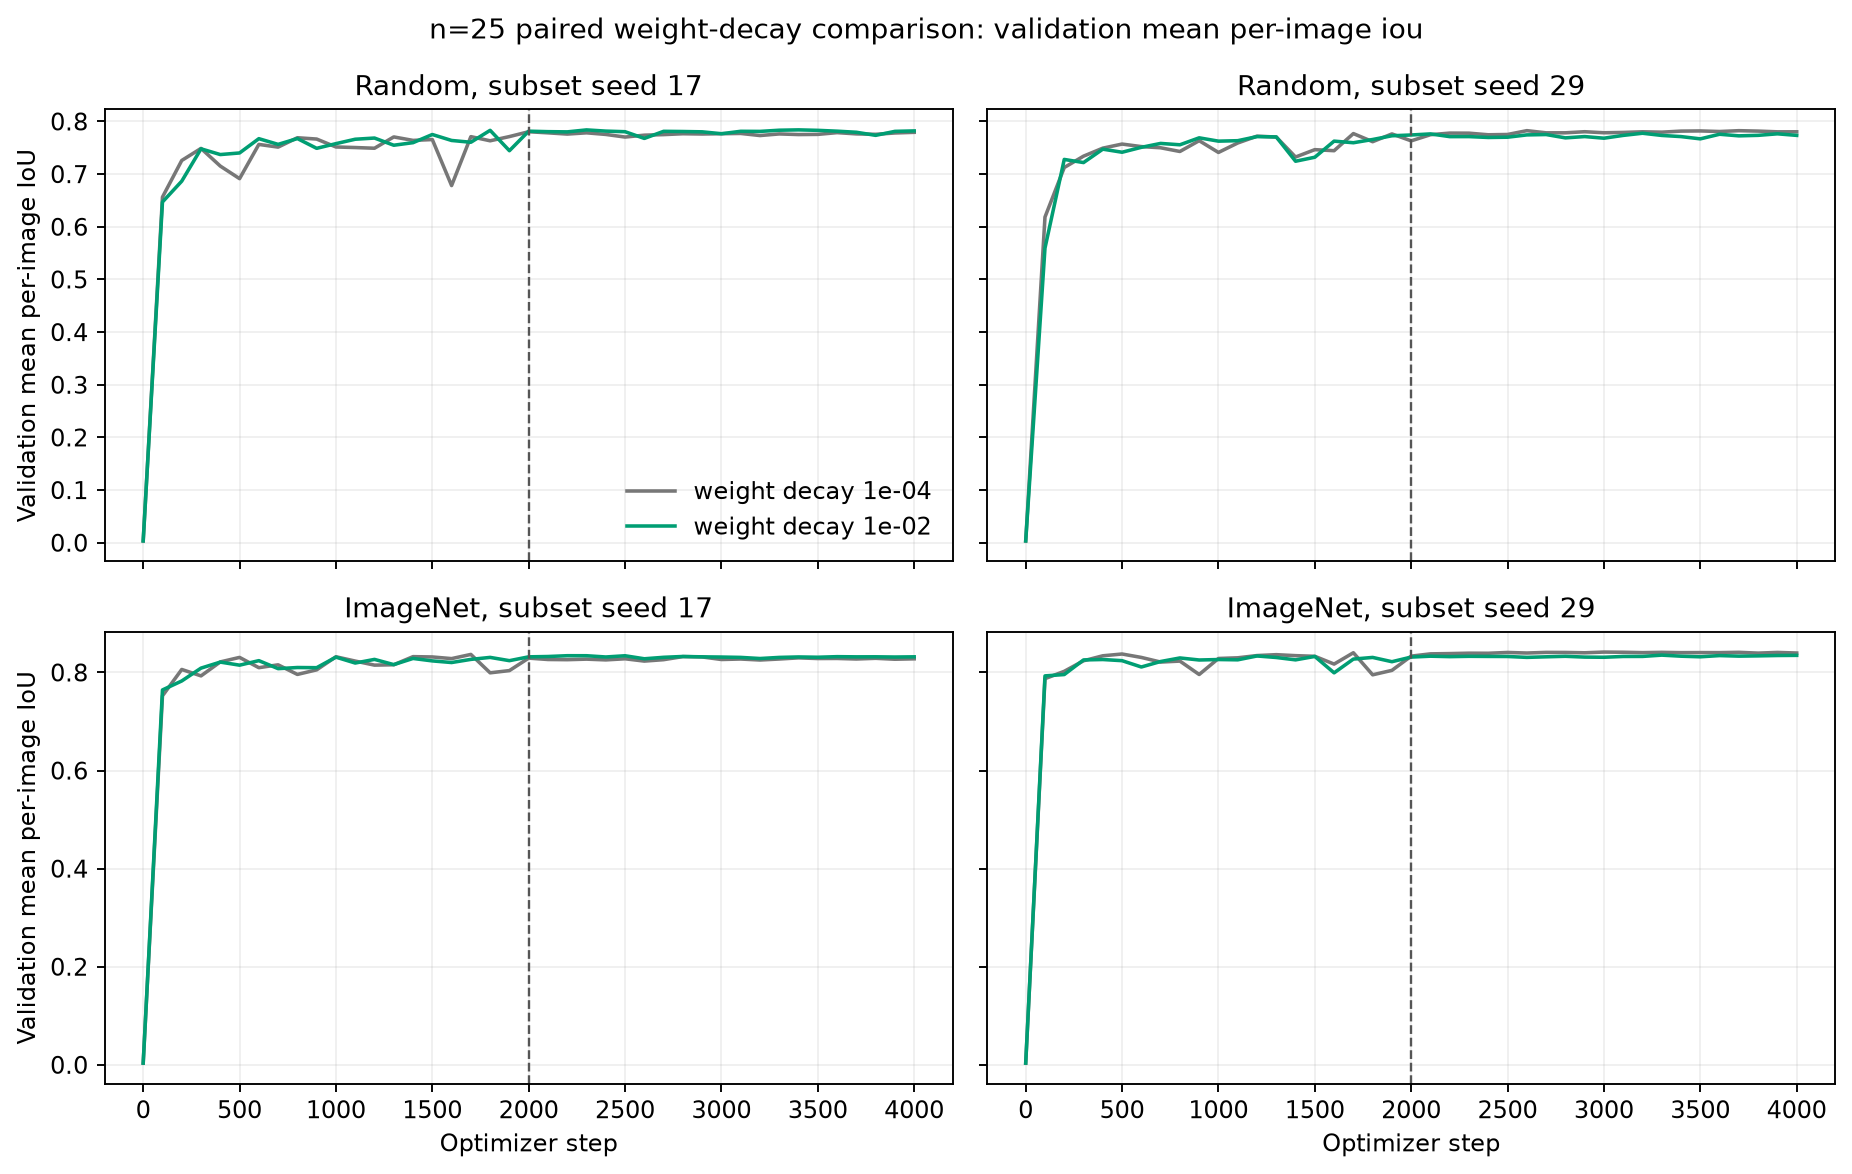

In [5]:
display(Image(filename=ROOT / 'reports/figures/weight_decay_n25_iou.png'))

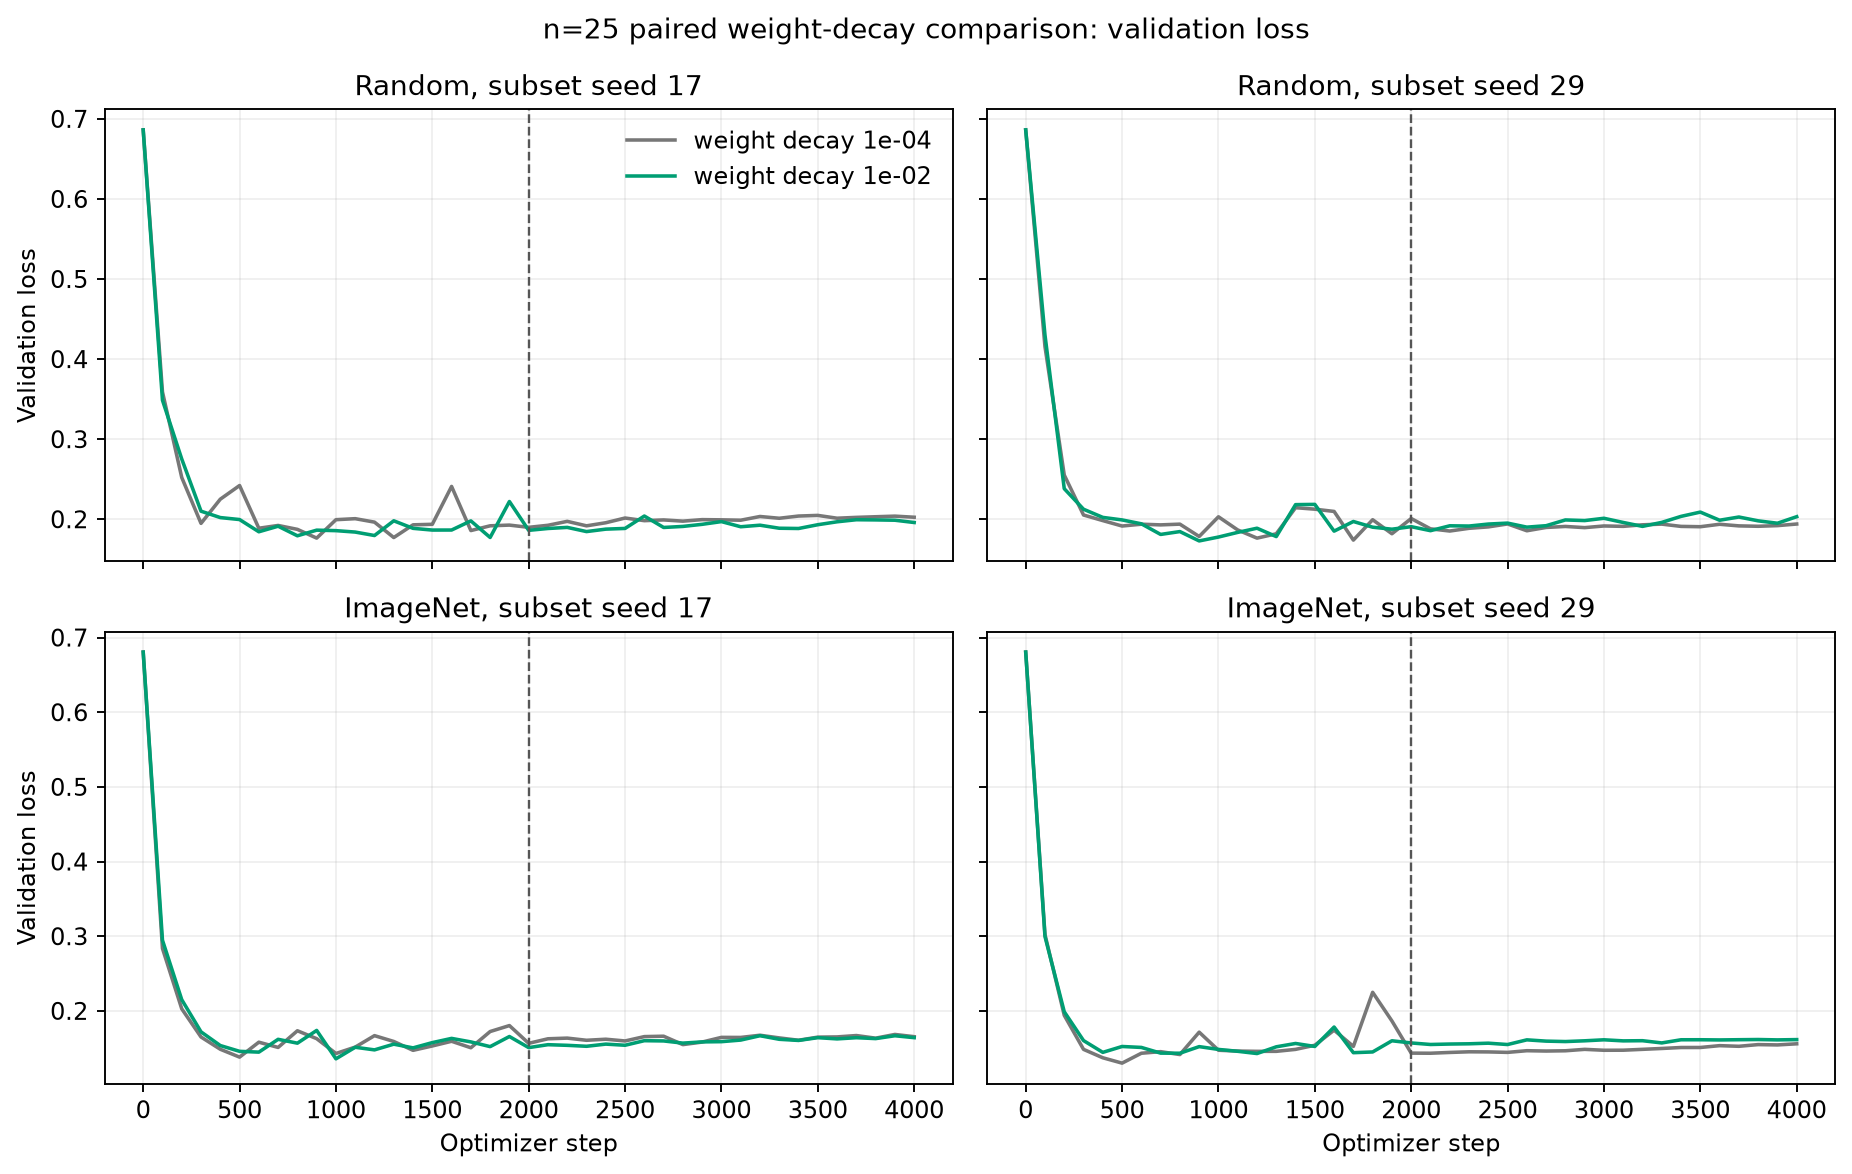

In [6]:
display(Image(filename=ROOT / 'reports/figures/weight_decay_n25_loss.png'))

The curves confirm that the result is not explained by one isolated selected checkpoint. Strong decay lowers Seed 17 Random loss late, but Seed 29 Random loss is higher. Both ImageNet strong-decay curves remain at or below their references in IoU. All four configurations still show positive late validation-loss trends, so `1e-2` does not remove the small-data overfitting pattern.

In [7]:
late_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'weight_decay': 'weight decay',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(RESULTS[list(late_columns)].rename(columns=late_columns).style.format({
    'weight decay': '{:.0e}', 'IoU trend / 1,000': '{:+.4f}',
    'IoU residual SD': '{:.4f}', 'loss trend / 1,000': '{:+.4f}',
    'loss residual SD': '{:.4f}',
}))

,seed,initialization,weight decay,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,imagenet,1e-04,+0.0010,0.0020,+0.0025,0.0029
1,17,imagenet,1e-02,-0.0007,0.0015,+0.0064,0.0020
2,17,random,1e-04,+0.0009,0.0020,+0.0051,0.0020
3,17,random,1e-02,+0.0004,0.0037,+0.0047,0.0041
4,29,imagenet,1e-04,+0.0008,0.0008,+0.0063,0.0009
5,29,imagenet,1e-02,+0.0011,0.0010,+0.0033,0.0014
6,29,random,1e-04,+0.0030,0.0016,+0.0027,0.0019
7,29,random,1e-02,+0.0010,0.0028,+0.0064,0.0040


Late stability also changes inconsistently. IoU residual standard deviation falls for Seed 17 ImageNet but rises for the other three pairs. Validation-loss trend improves for Seed 17 Random and Seed 29 ImageNet, while worsening for Seed 17 ImageNet and Seed 29 Random. A smoother curve in one pair therefore does not support a general benefit.

## 6. Comparable training and validation evaluation

Training metrics are recomputed at each selected checkpoint with augmentation disabled and evaluation mode enabled, matching validation preprocessing and model mode. This avoids comparing the augmented training objective directly with deterministic validation loss.

In [8]:
comparison_columns = {
    'subset_seed': 'seed', 'initialization': 'init', 'weight_decay': 'weight decay',
    'selected_training_loss': 'train loss',
    'selected_validation_loss': 'validation loss',
    'selected_training_iou': 'train IoU',
    'best_validation_iou': 'validation IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice',
    'selected_validation_dice': 'validation Dice',
    'selected_training_ap': 'train AP', 'selected_validation_ap': 'validation AP',
}
display(RESULTS[list(comparison_columns)].rename(columns=comparison_columns).style.format({
    'weight decay': '{:.0e}',
    **{column: '{:.3f}' for column in list(comparison_columns.values())[3:]},
}))

,seed,init,weight decay,train loss,validation loss,train IoU,validation IoU,IoU gap,train Dice,validation Dice,train AP,validation AP
0,17,imagenet,1e-04,0.020,0.151,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,imagenet,1e-02,0.019,0.154,0.967,0.834,0.133,0.983,0.904,0.999,0.949
2,17,random,1e-04,0.047,0.190,0.922,0.781,0.141,0.959,0.868,0.992,0.927
3,17,random,1e-02,0.039,0.188,0.932,0.784,0.148,0.964,0.871,0.994,0.932
4,29,imagenet,1e-04,0.017,0.147,0.972,0.842,0.130,0.986,0.908,0.999,0.959
5,29,imagenet,1e-02,0.016,0.157,0.973,0.835,0.137,0.986,0.904,0.999,0.952
6,29,random,1e-04,0.039,0.186,0.935,0.783,0.153,0.966,0.869,0.995,0.934
7,29,random,1e-02,0.035,0.191,0.942,0.778,0.164,0.970,0.867,0.996,0.931


## 7. Limitations and decision

This is a targeted validation experiment with two partially overlapping training subsets and one repeatedly used validation region. All non-subset random seeds are fixed, so it isolates the configured decay change but does not measure full training variance. Adjacent checkpoints are dependent, and two subset selections do not justify confidence intervals, significance claims or geographic generalization claims. The test region was absent from training, checkpoint selection and qualitative analysis.

The evidence does not support adopting `weight_decay=1e-2` for the n=25 recipe: the best-IoU effect is negative in three of four pairs, both ImageNet pairs worsen, Seed 29 worsens for both initializations, and the train–validation gap increases everywhere. This does not show that AdamW weight decay is generally ineffective; it shows that this predeclared strength is not robustly beneficial under the tested schedule.

The next most informative limited experiment is mild brightness/contrast augmentation at n=25, paired against the existing D4-only references across both subset selections and initializations. It directly targets limited appearance diversity rather than increasing parameter shrinkage. Its range and application order should be predeclared before execution. No follow-up experiment is run here.

## 8. Conclusion

Increasing AdamW weight decay from `1e-4` to `1e-2` produces one small favorable result for Seed 17 Random but fails to repeat across the second training-image selection or the pretrained models. It neither reduces the comparable train–validation gap nor consistently improves late loss and stability. The current `1e-4` recipe remains the stronger supported baseline for subsequent targeted work.